# Notebooks de collecte et analyse de données

## Importation des librairies

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Chargement des fichiers CSV fournis

In [14]:
listings = pd.read_csv('listings.csv')
reviews = pd.read_csv('reviews.csv')
neighbourhoods = pd.read_csv('neighbourhoods.csv')

## Affichage des données avant traitement

In [15]:
print("Listings avant traitement :")
print(listings.head())

print("\nReviews avant traitement :")
print(reviews.head())

print("\nNeighbourhoods avant traitement :")
print(neighbourhoods.head())

Listings avant traitement :
      id                                          name  host_id  host_name  \
0   5396  Your perfect Paris studio on Île Saint-Louis     7903     Borzou   
1   7964                  Sunny apartment with balcony    22155      Anaïs   
2   9952                     Paris petit coin douillet    33534  Elisabeth   
3  11487          Heart of  Paris, brand new aparment.    42666   Brigitte   
4  12452                                Voltaire Charm    48733      Irene   

   neighbourhood_group   neighbourhood  latitude  longitude        room_type  \
0                  NaN  Hôtel-de-Ville  48.85247    2.35835  Entire home/apt   
1                  NaN           Opéra  48.87417    2.34245  Entire home/apt   
2                  NaN      Popincourt  48.86238    2.36957  Entire home/apt   
3                  NaN      Popincourt  48.86351    2.37110  Entire home/apt   
4                  NaN      Popincourt  48.85974    2.37932  Entire home/apt   

   price  minimum_nigh

## Nettoyage dataset listings

In [16]:
print("\nNettoyage listings...")
df_listings = listings.copy()
df_listings = df_listings.drop_duplicates()
df_listings = df_listings.dropna(subset=['price', 'neighbourhood'])  # Suppression si pas de prix ou ville


Nettoyage listings...


## Nettoyage du format de la colonne 'price'

In [17]:
if df_listings['price'].dtype == 'object':
    df_listings['price'] = df_listings['price'].replace({'$':'', ',':''}, regex=True).astype(float)

## Remplacement des valeurs manquantes pour certains champs

In [18]:
valeurs_defaut = {'reviews_per_month': 0, 'bathrooms': 1, 'bedrooms': 1, 'beds': 1}
df_listings.fillna(valeurs_defaut, inplace=True)

## Encodage numérique de la ville

In [19]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df_listings['city_encoded'] = encoder.fit_transform(df_listings['neighbourhood'])

## Génération de dates fictives de réservation

In [20]:
np.random.seed(42)
df_listings['reservation_date'] = pd.to_datetime(
    np.random.choice(pd.date_range('2023-01-01', '2023-12-31'), size=len(df_listings))
)

## Fonction pour attribuer la saison (en fonction des date)

In [21]:
def get_season(date):
    if date.month in [12, 1, 2]:
        return 'Hiver'
    elif date.month in [3, 4, 5]:
        return 'Printemps'
    elif date.month in [6, 7, 8]:
        return 'Été'
    else:
        return 'Automne'

df_listings['saison'] = df_listings['reservation_date'].apply(get_season)

## Affichage des données listings après traitement

In [22]:
print("\nListings après traitement :")
print(df_listings.head())


Listings après traitement :
      id                                           name  host_id  host_name  \
0   5396   Your perfect Paris studio on Île Saint-Louis     7903     Borzou   
2   9952                      Paris petit coin douillet    33534  Elisabeth   
3  11487           Heart of  Paris, brand new aparment.    42666   Brigitte   
4  12452                                 Voltaire Charm    48733      Irene   
6  17287  Unique Loft in Paris near Parc de la Villette    64055      David   

   neighbourhood_group    neighbourhood  latitude  longitude        room_type  \
0                  NaN   Hôtel-de-Ville  48.85247    2.35835  Entire home/apt   
2                  NaN       Popincourt  48.86238    2.36957  Entire home/apt   
3                  NaN       Popincourt  48.86351    2.37110  Entire home/apt   
4                  NaN       Popincourt  48.85974    2.37932  Entire home/apt   
6                  NaN  Buttes-Chaumont  48.89772    2.38508  Entire home/apt   

   price 

## Reviews : Nettoyage simple

In [23]:
df_reviews = reviews.drop_duplicates()
print("\nReviews après traitement :")
print(df_reviews.head())


Reviews après traitement :
   listing_id        date
0        3109  2017-10-28
1        3109  2017-11-03
2        3109  2018-07-24
3        3109  2019-10-24
4        7397  2011-04-08


## Neighbourhoods : Nettoyage simple

In [24]:
print("\nNeighbourhoods après traitement :")
print(neighbourhoods.head())


Neighbourhoods après traitement :
   neighbourhood_group        neighbourhood
0                  NaN  Batignolles-Monceau
1                  NaN               Bourse
2                  NaN      Buttes-Chaumont
3                  NaN    Buttes-Montmartre
4                  NaN               Élysée


#Création de datasets fictifs enrichis

In [25]:
print("\nGénération de datasets fictifs...")


Génération de datasets fictifs...


## Génération de 1500 événements fictifs

In [26]:
events = pd.DataFrame({
    'event_id': range(1, 15001),
    'event_name': np.random.choice(['Festival', 'Salon', 'Concert', 'Compétition Sportive', 'Conférence'], size=15000),
    'neighbourhood': np.random.choice(df_listings['neighbourhood'].unique(), size=15000),
    'start_date': pd.to_datetime(np.random.choice(pd.date_range('2023-01-01', '2023-12-31'), size=15000)),
})
events['end_date'] = events['start_date'] + pd.to_timedelta(np.random.randint(1, 5, size=15000), unit='D')
events.to_csv('/content/events.csv', index=False)

print("\nExtrait events.csv :")
print(events.head())


Extrait events.csv :
   event_id  event_name      neighbourhood start_date   end_date
0         1     Concert             Élysée 2023-08-10 2023-08-14
1         2    Festival  Buttes-Montmartre 2023-03-14 2023-03-18
2         3     Concert           Gobelins 2023-06-23 2023-06-24
3         4  Conférence     Palais-Bourbon 2023-02-01 2023-02-03
4         5     Concert         Luxembourg 2023-03-26 2023-03-30


## Génération de 1500 lignes de météo

In [27]:
weather = pd.DataFrame({
    'date': pd.to_datetime(np.random.choice(pd.date_range('2023-01-01', '2023-12-31'), size=15000)),
    'neighbourhood': np.random.choice(df_listings['neighbourhood'].unique(), size=15000),
    'temperature_c': np.random.normal(20, 10, 15000).round(1),
    'rainfall_mm': np.random.exponential(scale=5, size=15000).round(1)
})
weather.to_csv('/content/weather.csv', index=False)

print("\nExtrait weather.csv :")
print(weather.head())


Extrait weather.csv :
        date    neighbourhood  temperature_c  rainfall_mm
0 2023-08-25        Vaugirard           28.6          1.7
1 2023-06-14         Panthéon           10.1          0.6
2 2023-03-17           Temple           30.4         10.3
3 2023-08-15  Buttes-Chaumont           -6.0         20.4
4 2023-02-01         Entrepôt           24.2         14.6


## Analyse exploratoire (EDA)

### Prix moyen par ville

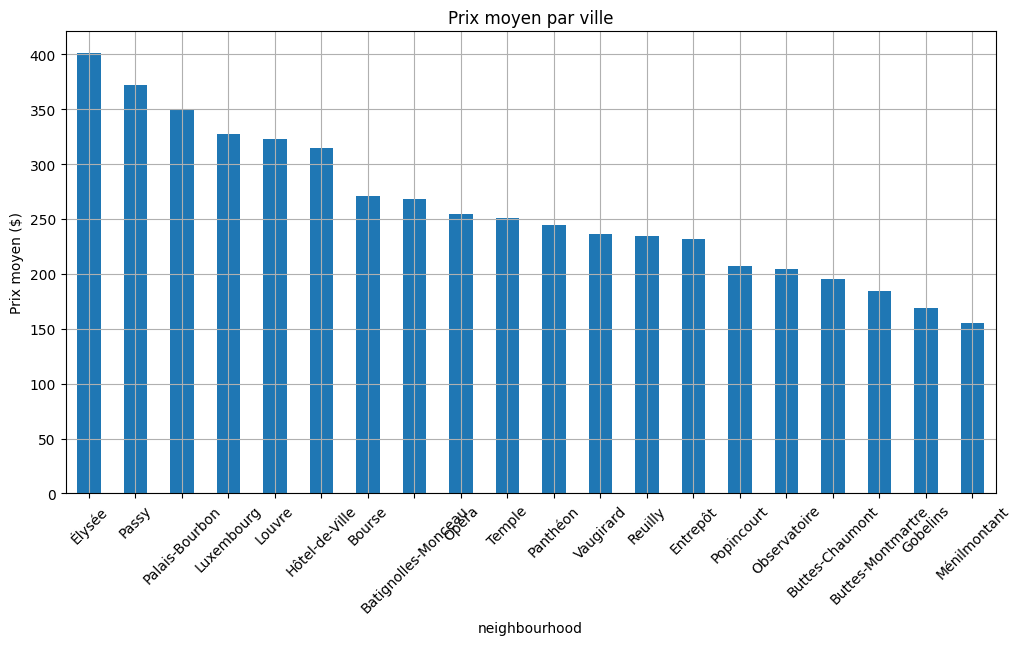

In [28]:
avg_price_city = df_listings.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(12,6))
avg_price_city.plot(kind='bar')
plt.title('Prix moyen par ville')
plt.ylabel('Prix moyen ($)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

### Prix moyen par saison

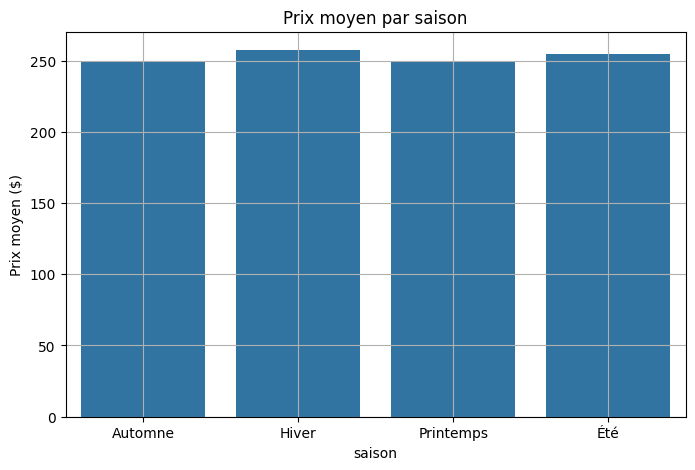

In [29]:
avg_price_saison = df_listings.groupby('saison')['price'].mean()

plt.figure(figsize=(8,5))
sns.barplot(x=avg_price_saison.index, y=avg_price_saison.values)
plt.title('Prix moyen par saison')
plt.ylabel('Prix moyen ($)')
plt.grid()
plt.show()

### Comparaison type de logement

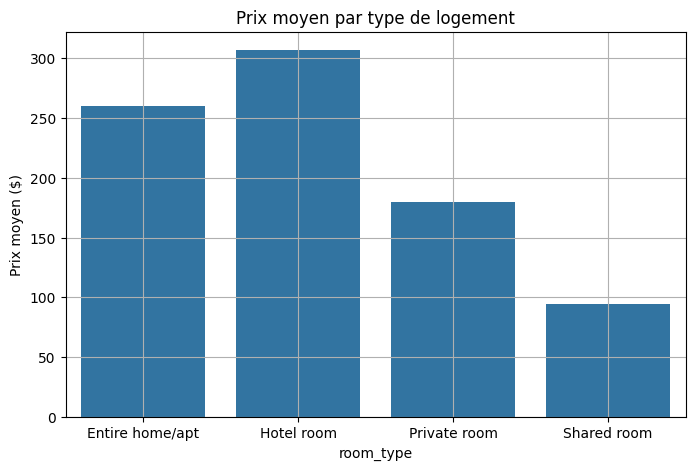

In [30]:
if 'room_type' in df_listings.columns:
    avg_price_room = df_listings.groupby('room_type')['price'].mean()

    plt.figure(figsize=(8,5))
    sns.barplot(x=avg_price_room.index, y=avg_price_room.values)
    plt.title('Prix moyen par type de logement')
    plt.ylabel('Prix moyen ($)')
    plt.grid()
    plt.show()

# Export final des datasets traités

In [31]:
df_listings.to_csv('/content/listings_clean.csv', index=False)
df_reviews.to_csv('/content/reviews_clean.csv', index=False)
neighbourhoods.to_csv('/content/neighbourhoods_clean.csv', index=False)

print("\nFichiers exportés :")
print("- listings_clean.csv")
print("- reviews_clean.csv")
print("- neighbourhoods_clean.csv")
print("- events.csv")
print("- weather.csv")


Fichiers exportés :
- listings_clean.csv
- reviews_clean.csv
- neighbourhoods_clean.csv
- events.csv
- weather.csv


#  Rapport synthétique

In [35]:

rapport = """
# Rapport Synthétique - Analyse Exploratoire Airbnb

## Nettoyage des Données
- Listings : suppression doublons, nettoyage prix, ajout saison.
- Reviews : suppression doublons.
- Neighbourhoods : utilisé brut.

## Nouveaux jeux de données
- events.csv : 1500 événements aléatoires par ville/date.
- weather.csv : 1500 enregistrements météo simulés.

## Résultats clés
- Le prix varie fortement selon la ville et la saison.
- L'été est la saison la plus chère en moyenne.
- Les logements entiers sont plus chers que les chambres privées.

"""
print(rapport)


# Rapport Synthétique - Analyse Exploratoire Airbnb

## Nettoyage des Données
- Listings : suppression doublons, nettoyage prix, ajout saison.
- Reviews : suppression doublons.
- Neighbourhoods : utilisé brut.

## Nouveaux jeux de données
- events.csv : 1500 événements aléatoires par ville/date.
- weather.csv : 1500 enregistrements météo simulés.

## Résultats clés
- Le prix varie fortement selon la ville et la saison.
- L'été est la saison la plus chère en moyenne.
- Les logements entiers sont plus chers que les chambres privées.


